In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
all_data  = pd.read_csv("new_nifty_top15_prices_2010_2024.csv",index_col= "Date" ,parse_dates = ["Date"]).dropna()
all_data

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,RELIANCE.NS,SBIN.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2010-01-04,180.627899,3.028105,270.075684,62.352825,73.725151,197.109497,133.353134,217.472565,48.353577,40.643486,597.963867,237.022522,217.587051,185.358688,259.259125,5232.200195
2010-01-05,184.396698,3.007806,274.352753,63.755787,73.790016,196.476517,134.618912,218.200943,48.830139,41.046024,599.024597,241.385986,216.615967,185.427460,259.328064,5277.899902
2010-01-06,181.301559,3.051052,271.445984,61.831932,73.839699,197.593491,135.649689,215.017014,48.944515,41.544872,592.395752,247.175949,220.115952,186.539856,253.464539,5281.799805
2010-01-07,182.585129,3.032518,273.563782,60.512951,74.032036,197.183914,134.368774,210.184967,48.792023,42.011608,589.549744,242.466354,223.767700,185.496201,246.410782,5263.100098
2010-01-08,184.970200,3.087678,269.951141,59.101585,74.129272,198.040314,132.481491,205.119812,48.896866,41.752316,593.279724,242.487350,223.181015,184.942062,241.375076,5244.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,1078.228516,682.458862,1573.743652,1785.912354,874.034241,2296.506836,1286.870483,1829.401367,420.904694,348.667999,3571.972412,2886.112793,1211.834717,790.733276,3893.971436,23753.449219
2024-12-24,1077.978760,676.644775,1570.768555,1780.234375,872.626892,2293.217529,1287.317017,1814.903442,424.632233,349.407135,3571.236572,2905.358154,1212.280884,781.970276,3913.824463,23727.650391
2024-12-26,1075.780518,677.395142,1586.239258,1783.800903,869.059875,2290.468262,1287.416138,1813.334839,423.300964,350.156281,3561.179688,2951.933838,1206.133911,782.355469,3904.085205,23750.199219


In [3]:
all_data_return = np.log(all_data/all_data.shift()).dropna()

In [4]:
for i in all_data_return.columns:
    result  = adfuller(all_data_return[i])[1]
    if result < 0.05:
        print (f"{i} is stationry p value {result} is  less then 0.05 'PASS'")
    else:
        print (f"{i} is non stationry p value {result} is not less then 0.05 'FAIL'")

AXISBANK.NS is stationry p value 1.5493064391955703e-23 is  less then 0.05 'PASS'
BAJFINANCE.NS is stationry p value 1.3112234996799623e-27 is  less then 0.05 'PASS'
BHARTIARTL.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HCLTECH.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HDFCBANK.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HINDUNILVR.NS is stationry p value 0.0 is  less then 0.05 'PASS'
ICICIBANK.NS is stationry p value 4.910755277722277e-30 is  less then 0.05 'PASS'
INFY.NS is stationry p value 0.0 is  less then 0.05 'PASS'
ITC.NS is stationry p value 3.935954729916087e-30 is  less then 0.05 'PASS'
KOTAKBANK.NS is stationry p value 0.0 is  less then 0.05 'PASS'
LT.NS is stationry p value 7.259311008194966e-27 is  less then 0.05 'PASS'
M&M.NS is stationry p value 0.0 is  less then 0.05 'PASS'
RELIANCE.NS is stationry p value 2.1383574921395156e-27 is  less then 0.05 'PASS'
SBIN.NS is stationry p value 2.8283022216868785e-25 is  less then 0.05 'PASS'
TCS.N

# Feature enginnering 

In [6]:
new_feautre_data = all_data_return.copy()

In [7]:
new_feautre_data

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,RELIANCE.NS,SBIN.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2010-01-05,0.020650,-0.006726,0.015712,0.022251,0.000879,-0.003216,0.009447,0.003344,0.009808,0.009855,0.001772,0.018242,-0.004473,0.000371,0.000266,0.008696
2010-01-06,-0.016928,0.014276,-0.010652,-0.030640,0.000673,0.005669,0.007628,-0.014699,0.002340,0.012080,-0.011128,0.023703,0.016028,0.005981,-0.022870,0.000739
2010-01-07,0.007055,-0.006093,0.007772,-0.021563,0.002601,-0.002075,-0.009488,-0.022729,-0.003120,0.011172,-0.004816,-0.019237,0.016454,-0.005611,-0.028224,-0.003547
2010-01-08,0.012978,0.018026,-0.013294,-0.023600,0.001313,0.004334,-0.014145,-0.024394,0.002146,-0.006191,0.006307,0.000087,-0.002625,-0.002992,-0.020648,-0.003493
2010-01-11,0.032394,0.024982,0.011927,0.009901,-0.004031,0.000564,-0.005220,0.010275,0.000390,0.003837,-0.000507,0.002851,-0.019821,-0.008280,0.020368,0.000886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.006788,0.002690,0.005561,-0.004378,0.016515,0.002140,0.006499,0.001118,0.020450,0.001032,0.002930,0.001015,0.014006,0.011206,-0.002882,0.007011
2024-12-24,-0.000232,-0.008556,-0.001892,-0.003184,-0.001611,-0.001433,0.000347,-0.007957,0.008817,0.002118,-0.000206,0.006646,0.000368,-0.011144,0.005085,-0.001087
2024-12-26,-0.002041,0.001108,0.009801,0.002001,-0.004096,-0.001200,0.000077,-0.000865,-0.003140,0.002142,-0.002820,0.015904,-0.005083,0.000492,-0.002492,0.000950


In [8]:
# all_data_return["AXISBANK.NS_Lag_1" ] =all_data_return["AXISBANK.NS_Lag_1" ] .shift(1)
# Lag 1 feature 
for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_1" ] = all_data_return[i] .shift(1)
for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_5" ] = all_data_return[i] .shift(5)


for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_10" ] = all_data_return[i] .shift(10)


for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_10_mean" ] = all_data_return[i] .shift(1).rolling(10).mean()

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_50_mean" ] = all_data_return[i] .shift(1).rolling(50).mean()

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_200_mean" ] = all_data_return[i] .shift(1).rolling(200).mean()

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_10_ema" ] = all_data_return[i] .shift(1).ewm(span= 10).mean()

for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_50_ema" ] = all_data_return[i] .shift(1).ewm(span = 50).mean()



for i in all_data_return.columns:
    new_feautre_data[f"{i}_Lag_200_ema" ] = all_data_return[i] .shift(1).ewm(span =200).mean()

In [9]:
new_feautre_data.columns

Index(['AXISBANK.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'HCLTECH.NS',
       'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS',
       'KOTAKBANK.NS',
       ...
       'ICICIBANK.NS_Lag_200_ema', 'INFY.NS_Lag_200_ema', 'ITC.NS_Lag_200_ema',
       'KOTAKBANK.NS_Lag_200_ema', 'LT.NS_Lag_200_ema', 'M&M.NS_Lag_200_ema',
       'RELIANCE.NS_Lag_200_ema', 'SBIN.NS_Lag_200_ema', 'TCS.NS_Lag_200_ema',
       '^NSEI_Lag_200_ema'],
      dtype='object', length=160)

In [10]:
new_feautre_data["Target"] =  (new_feautre_data["^NSEI"].shift(-1)>0).astype(int)

In [11]:
new_feautre_data.drop(columns= "^NSEI",inplace =  True)

In [12]:
df = new_feautre_data.dropna().copy()

X = df.drop(columns=["Target"])
y = df["Target"]

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

In [14]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (2434, 159)
Scaled X_test shape: (1044, 159)


In [15]:
knn = KNeighborsClassifier(n_neighbors= round(np.sqrt(len(X.columns))))


In [16]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"]
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=1
)

grid.fit(X_train_scaled, Y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'n_neighbors': 15, 'weights': 'uniform'}
Best CV score: 0.494320987654321


In [17]:
best_knn = grid.best_estimator_

In [18]:
Y_train_pred = best_knn.predict(X_train_scaled)
Y_test_pred = best_knn.predict(X_test_scaled)


In [19]:
train_acc = accuracy_score(Y_train, Y_train_pred)
test_acc = accuracy_score(Y_test, Y_test_pred)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.6166803615447822
Test Accuracy: 0.5402298850574713


In [20]:
print("TRAIN CLASSIFICATION REPORT")
print(classification_report(Y_train, Y_train_pred))

print("TEST CLASSIFICATION REPORT")
print(classification_report(Y_test, Y_test_pred))

TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.60      0.59      0.59      1163
           1       0.63      0.64      0.64      1271

    accuracy                           0.62      2434
   macro avg       0.62      0.62      0.62      2434
weighted avg       0.62      0.62      0.62      2434

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.48      0.38      0.42       462
           1       0.58      0.66      0.62       582

    accuracy                           0.54      1044
   macro avg       0.53      0.52      0.52      1044
weighted avg       0.53      0.54      0.53      1044



In [21]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * Y_test_pred

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 108.36%
Buy & Hold Return      : 92.73%
Strategy Outperforms   : True


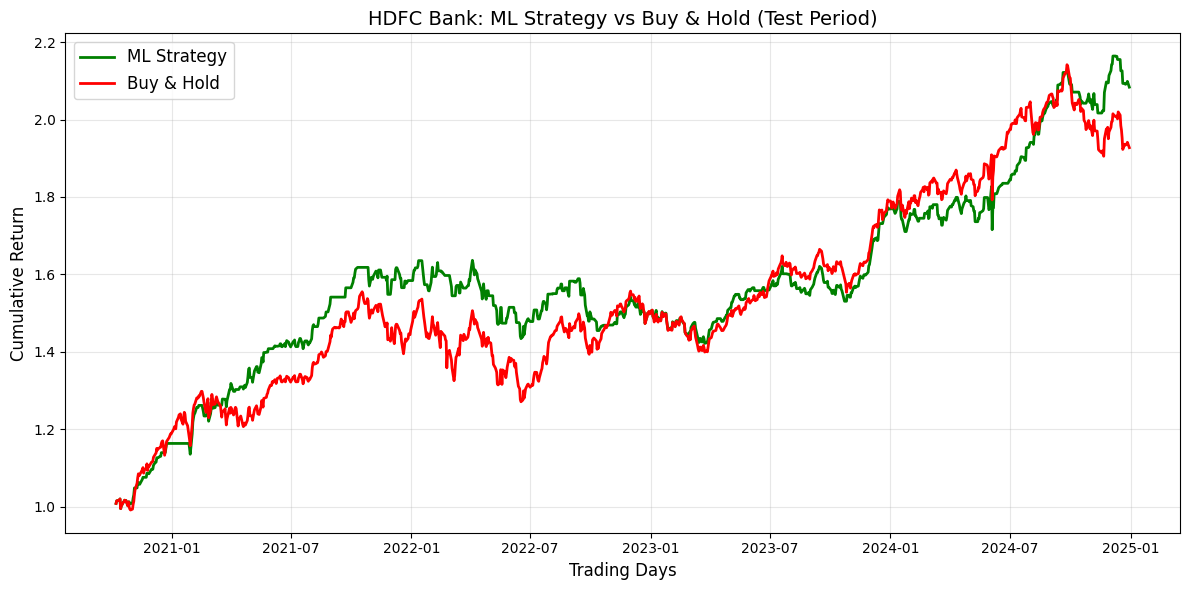

In [22]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_train.index, '^NSEI']
Y_train_pred = best_knn.predict(X_train_scaled)

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * Y_train_pred

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 1214.00%
Buy & Hold Return      : 68.17%
Strategy Outperforms   : True


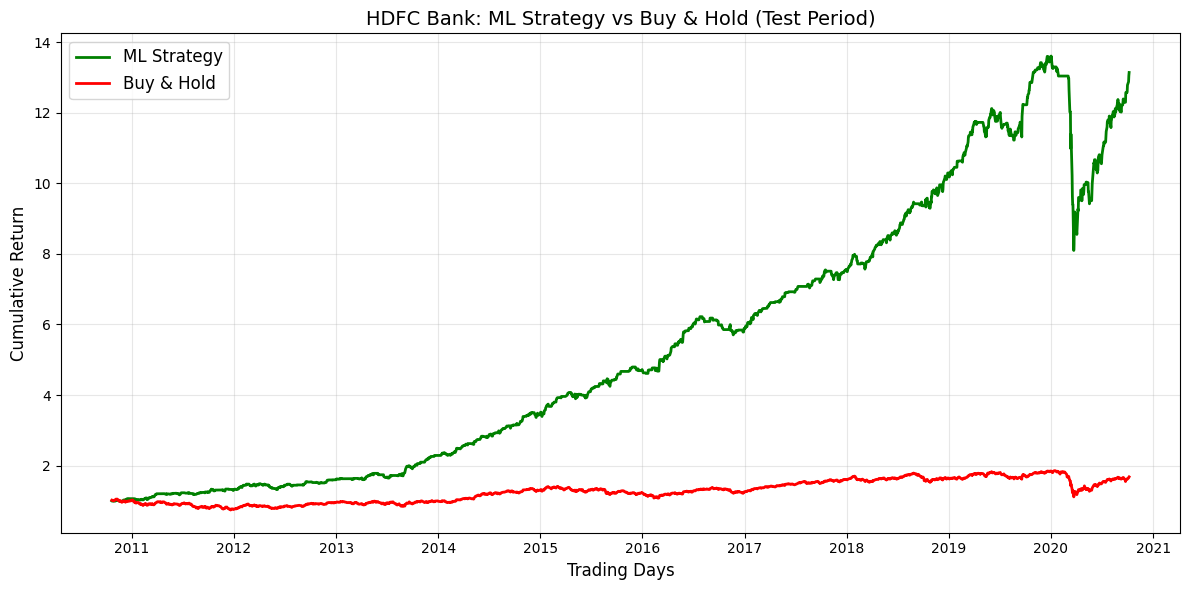

In [49]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()